# Simple Random Forest — MS Subtype Classification

**Goal:** Classify MS subtypes using an ensemble of decision trees.

**About Random Forest:** Builds many decision trees on random subsets of data and features, then lets them vote. No scaling needed — trees use thresholds, not distances.

---

In [1]:
# Import all the libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier
# Set seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13,
    'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3,
})

COLORS = {'RRMS': '#2196F3', 'SPMS': '#FF5722', 'PPMS': '#4CAF50', 'CIS': '#9C27B0'}
ORDER = ['RRMS', 'SPMS', 'PPMS', 'CIS']

print("All libraries loaded successfully!")

All libraries loaded successfully!


## 2. Loading the Dataset

We load the CSV file and take a quick look at its shape and first few rows.

In [2]:
df = pd.read_csv('../datasets/ms_dataset.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 565, Columns: 17


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,44.0,0,38.0,6.0,6.0,0.0,0.0,1028167.8,621739.1,474379.0,36.0,6807.9,0.261700,0.604700,0.461400,0.006621,PPMS
1,50.0,1,47.0,5.7,3.0,0.0,0.0,1309256.4,442370.6,466771.9,34.0,21719.1,0.463300,0.337900,0.356500,0.016589,PPMS
2,31.0,0,29.0,2.5,2.0,0.0,0.0,1493401.0,742487.0,513052.0,6.0,200.0,1.250000,0.497179,0.343546,0.000134,RRMS
3,50.0,0,42.0,5.7,8.0,0.0,1.0,1347866.4,604577.7,460298.3,3.0,19638.3,0.569400,0.448500,0.341500,0.014570,PPMS
4,39.6,0,37.0,2.0,2.6,1.0,0.0,1730165.0,732144.0,396716.0,8.0,404.0,0.769231,0.423164,0.229294,0.000234,CIS


## 3. Exploring the Data

Before building a model, we need to understand our data — check for missing values, see how many patients are in each subtype, and look at feature distributions.

### 3.1 Basic Info

In [3]:
print("Data types:")
print(df.dtypes)
print("\nBasic statistics:")
df.describe().round(2)

Data types:
age                      float64
sex_encoded                int64
age_at_onset             float64
edss                     float64
disease_duration         float64
relapse_count            float64
treatment_status         float64
brain_volume             float64
gm_volume                float64
wm_volume                float64
lesion_count             float64
lesion_volume            float64
edss_progression_rate    float64
gm_ratio                 float64
wm_ratio                 float64
lesion_burden_ratio      float64
subtype                      str
dtype: object

Basic statistics:


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio
count,565.00,565.00,565.00,565.00,565.00,565.00,565.00,565.00,565.00,565.00,565.00,565.00,539.00,565.00,565.00,565.00
mean,41.30,0.38,33.67,3.26,7.63,0.57,0.63,1364957.22,640627.73,440260.49,31.32,9692.20,0.82,0.47,0.32,0.01
std,12.47,0.49,10.01,2.12,6.56,0.62,0.48,157237.55,101924.25,59792.20,42.43,10037.31,1.52,0.08,0.05,0.01
min,15.00,0.00,7.50,0.00,0.00,0.00,0.00,922515.10,368110.90,268459.00,0.00,0.00,0.00,0.29,0.19,0.00
25%,31.00,0.00,26.70,1.50,2.90,0.00,0.00,1265129.00,578046.00,399868.00,10.00,2014.00,0.24,0.43,0.29,0.00
50%,40.60,0.00,33.20,3.00,5.80,0.00,1.00,1377883.00,652455.00,444134.00,22.00,6539.00,0.45,0.47,0.33,0.00
75%,51.00,1.00,40.00,5.00,11.40,1.00,1.00,1473326.00,716741.00,476837.00,40.00,14194.00,0.80,0.52,0.35,0.01
max,71.00,1.00,65.00,8.50,35.00,2.00,1.00,1730165.00,884733.00,628779.00,497.00,60999.00,20.00,0.86,0.49,0.05


In [4]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
edss_progression_rate    26
dtype: int64

Duplicate rows: 0


### 3.2 How Many Patients in Each Subtype?

subtype
RRMS    275
SPMS    125
PPMS    125
CIS      40
Name: count, dtype: int64


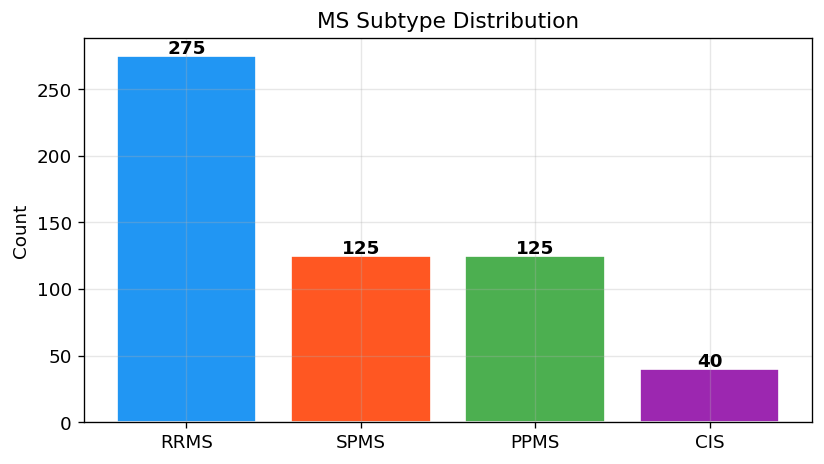

In [5]:
counts = df['subtype'].value_counts().reindex(ORDER)
print(counts)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(ORDER, counts, color=[COLORS[s] for s in ORDER], edgecolor='white')
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2, str(c), ha='center', fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('MS Subtype Distribution')
plt.tight_layout()
plt.show()

### 3.3 Feature Distributions by Subtype

Boxplots help us see which features differ across subtypes — features with clear separation will be helpful for classification.

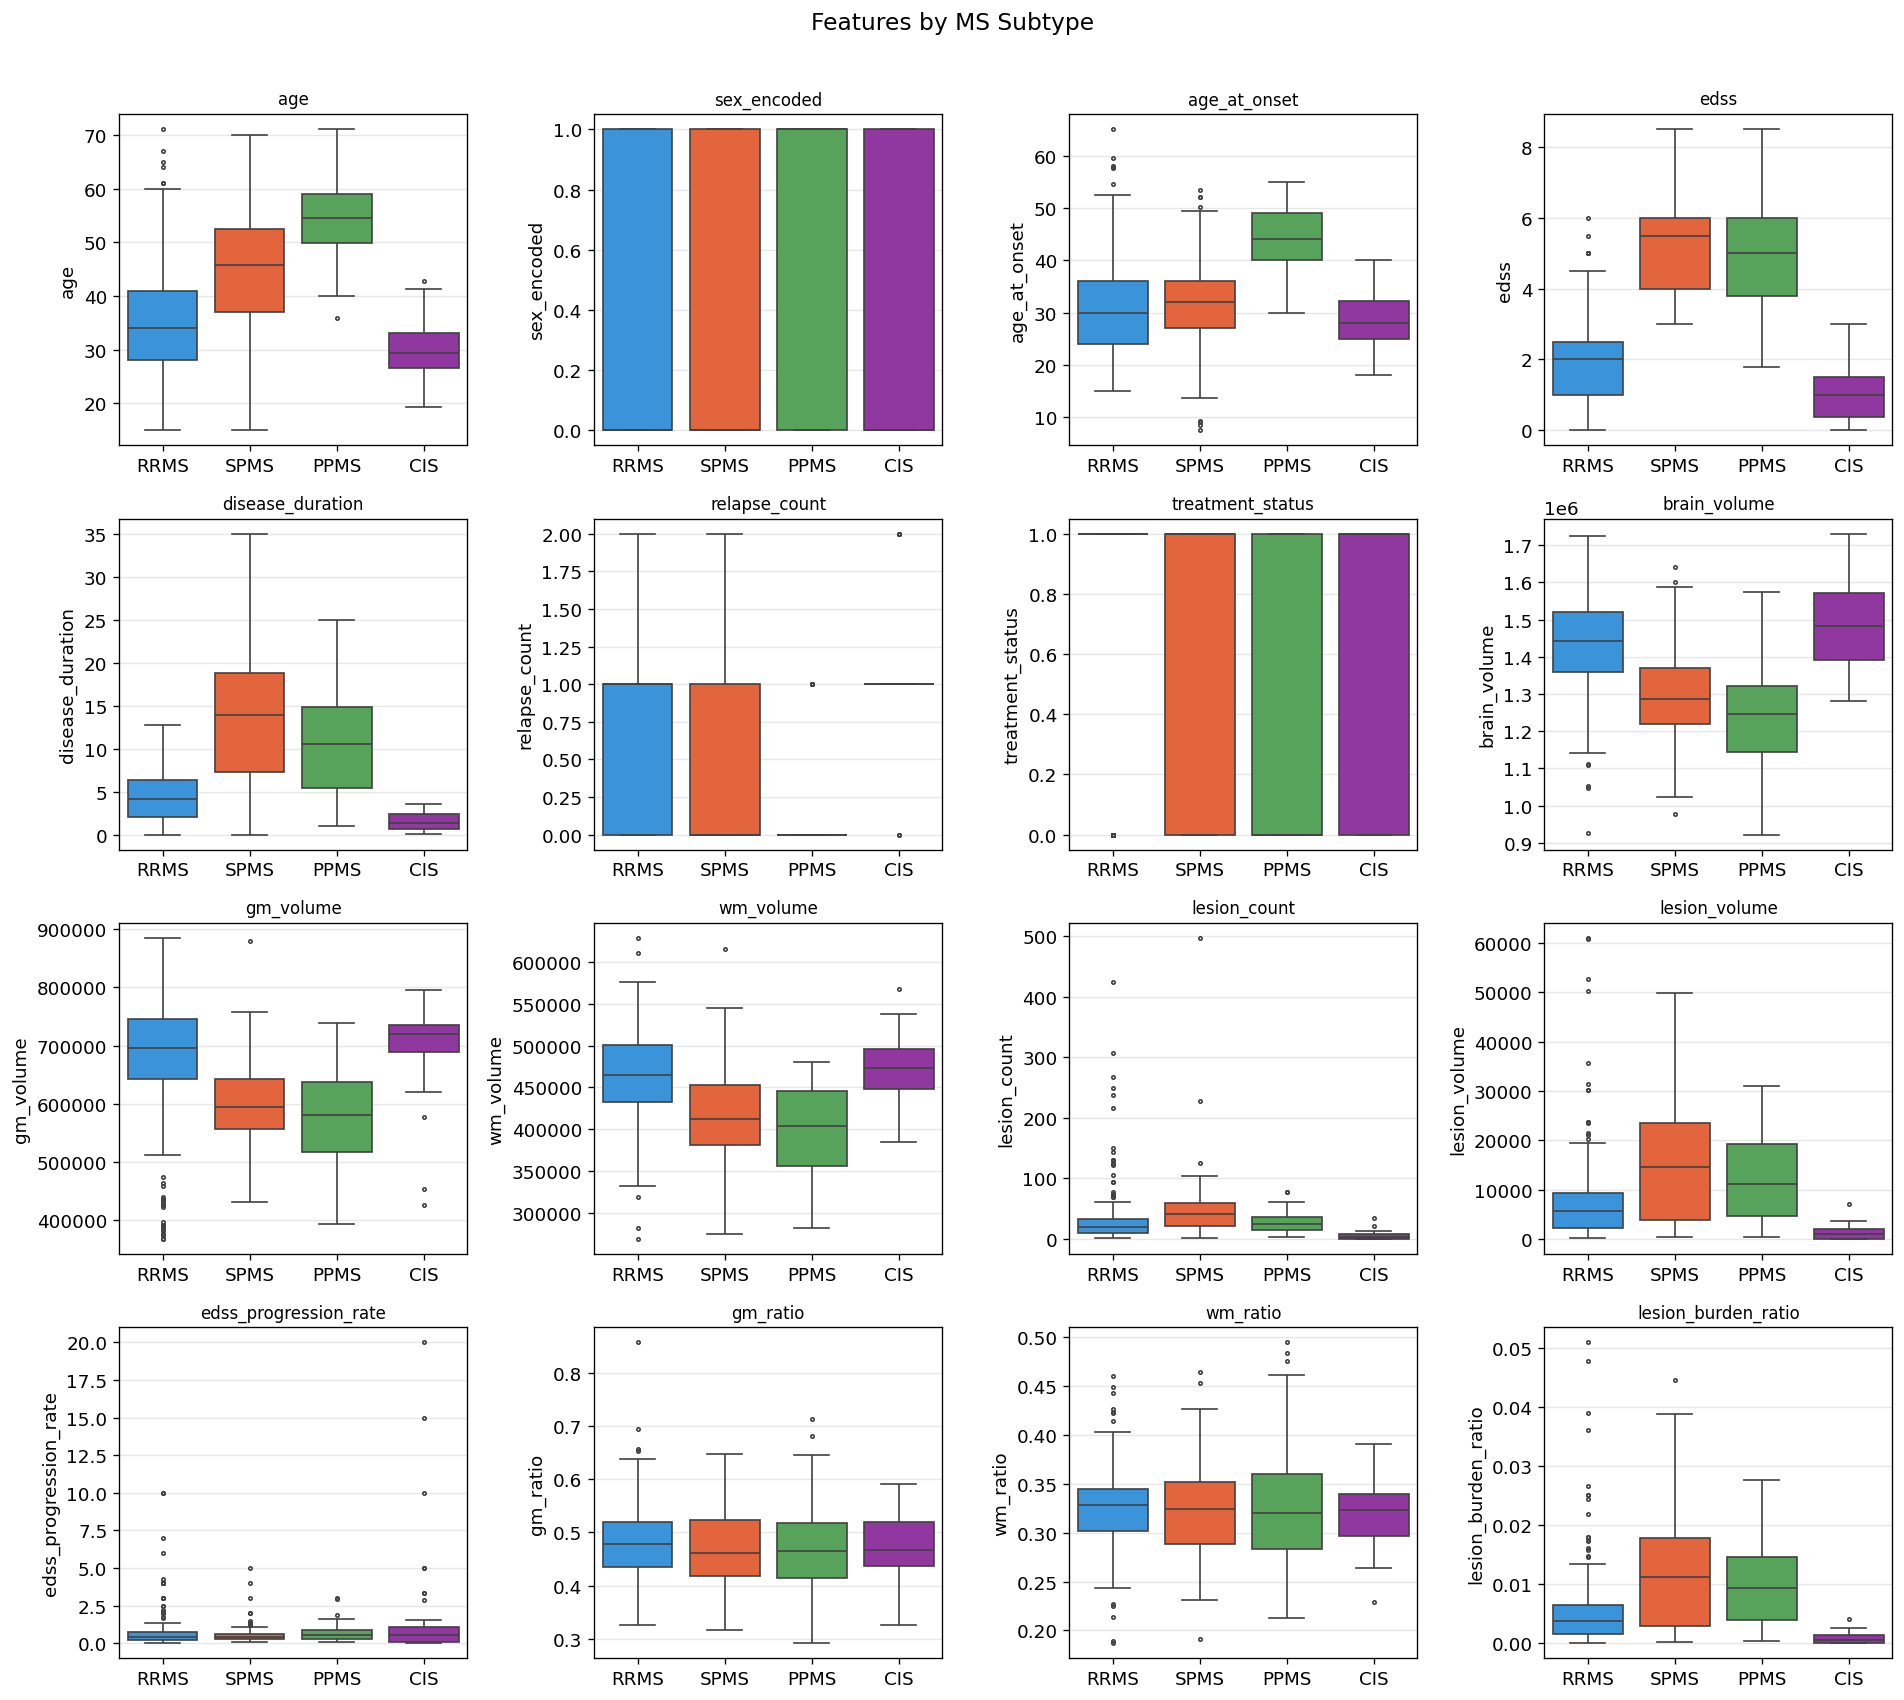

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
ncols = 4
nrows = (len(numeric_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='subtype', y=col, order=ORDER, palette=COLORS, ax=axes[i], fliersize=2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Features by MS Subtype', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

Shows how features relate to each other. Highly correlated features carry similar information.

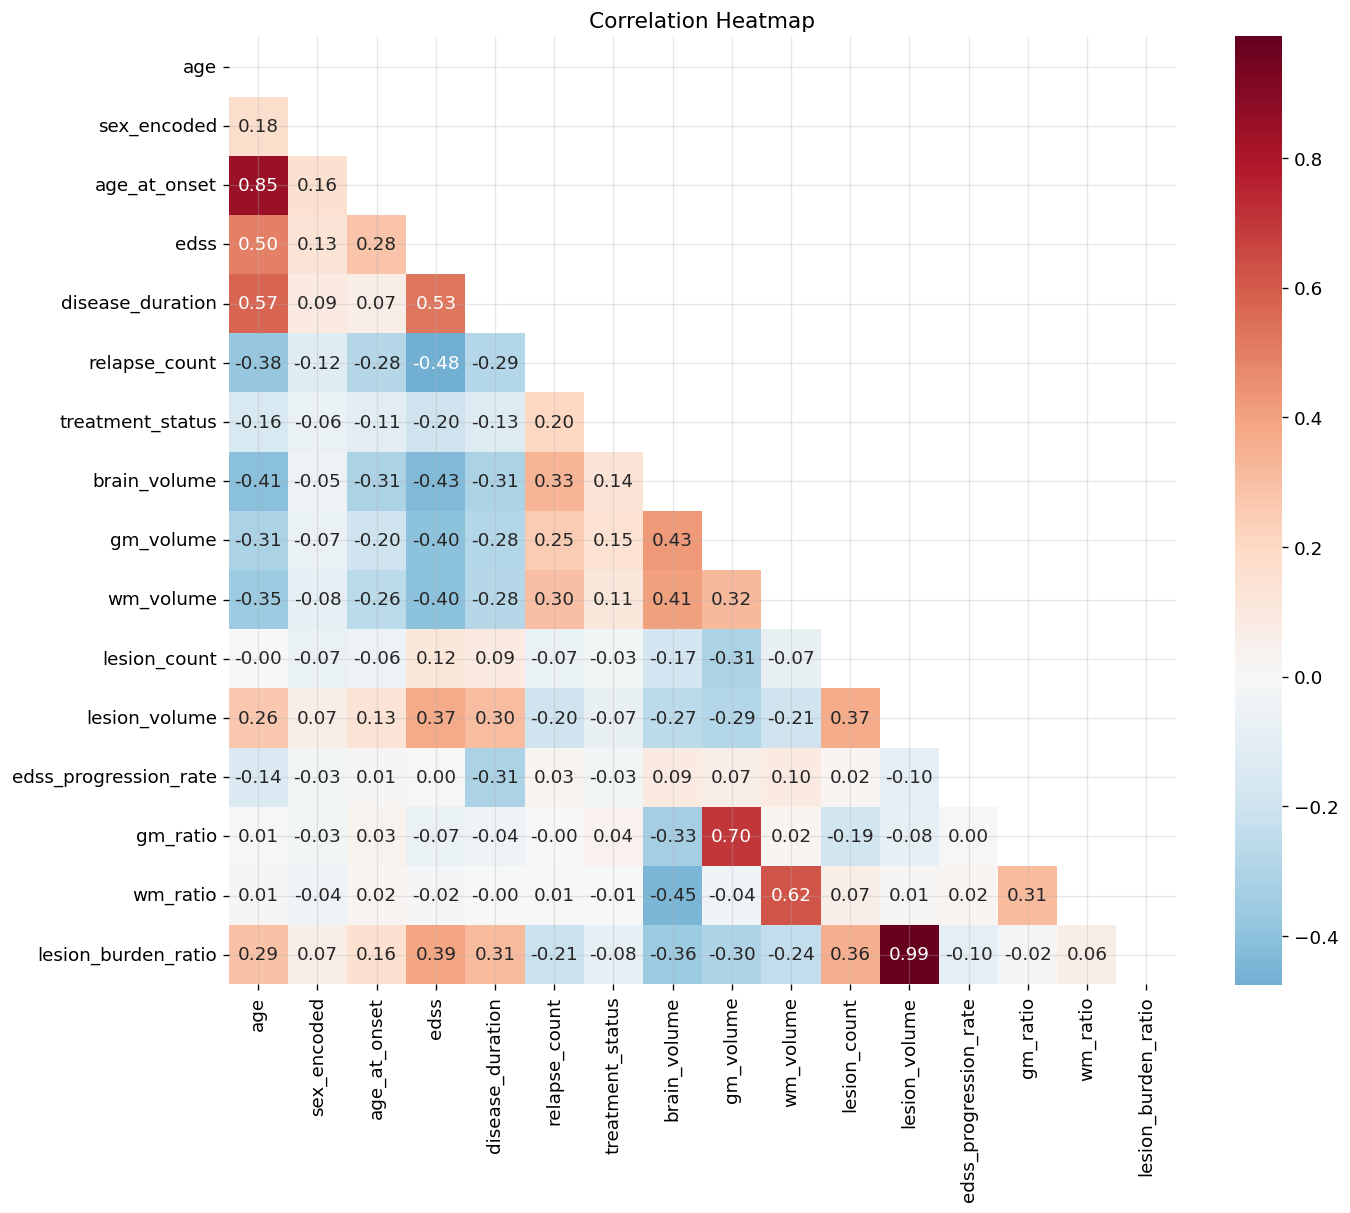

In [7]:
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Steps:
1. Separate features (X) from target (y)
2. Encode target labels as numbers
3. Split into 80% train / 20% test
4. Fill missing values with the median


**Important:** We fit the imputer only on training data to prevent data leakage.

In [8]:
# Separate features and target
feature_cols = [c for c in df.columns if c != 'subtype']
X = df[feature_cols]
y = df['subtype']

# Encode target as numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
print(f"Classes: {list(class_names)}")

Classes: ['CIS', 'PPMS', 'RRMS', 'SPMS']


In [9]:
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 452, Test: 113


In [10]:
# Fill missing values with median
imputer = SimpleImputer(strategy='median')


# Tree-based models don't need scaling
X_train_ready = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_ready = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)
print(f"Missing values remaining: 0")

Missing values remaining: 0


## 5. Building the Model

300 trees, balanced class weights, and OOB (out-of-bag) scoring for free validation.

In [11]:
model = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    oob_score=True, n_jobs=-1, random_state=RANDOM_STATE
)
print("Model created")

Model created


## 6. Cross-Validation (5-Fold)

We split training data into 5 parts, train on 4 and test on 1, rotating each time. This tells us how stable the model is.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'f1_weighted': 'f1_weighted'}

cv_results = cross_validate(model, X_train_ready, y_train, cv=cv, scoring=scoring)

print("Cross-Validation Results:")
print(f"  Accuracy:     {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"  Macro F1:     {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"  Weighted F1:  {cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}")

Cross-Validation Results:
  Accuracy:     0.8628 ± 0.0242
  Macro F1:     0.7725 ± 0.0599
  Weighted F1:  0.8530 ± 0.0272


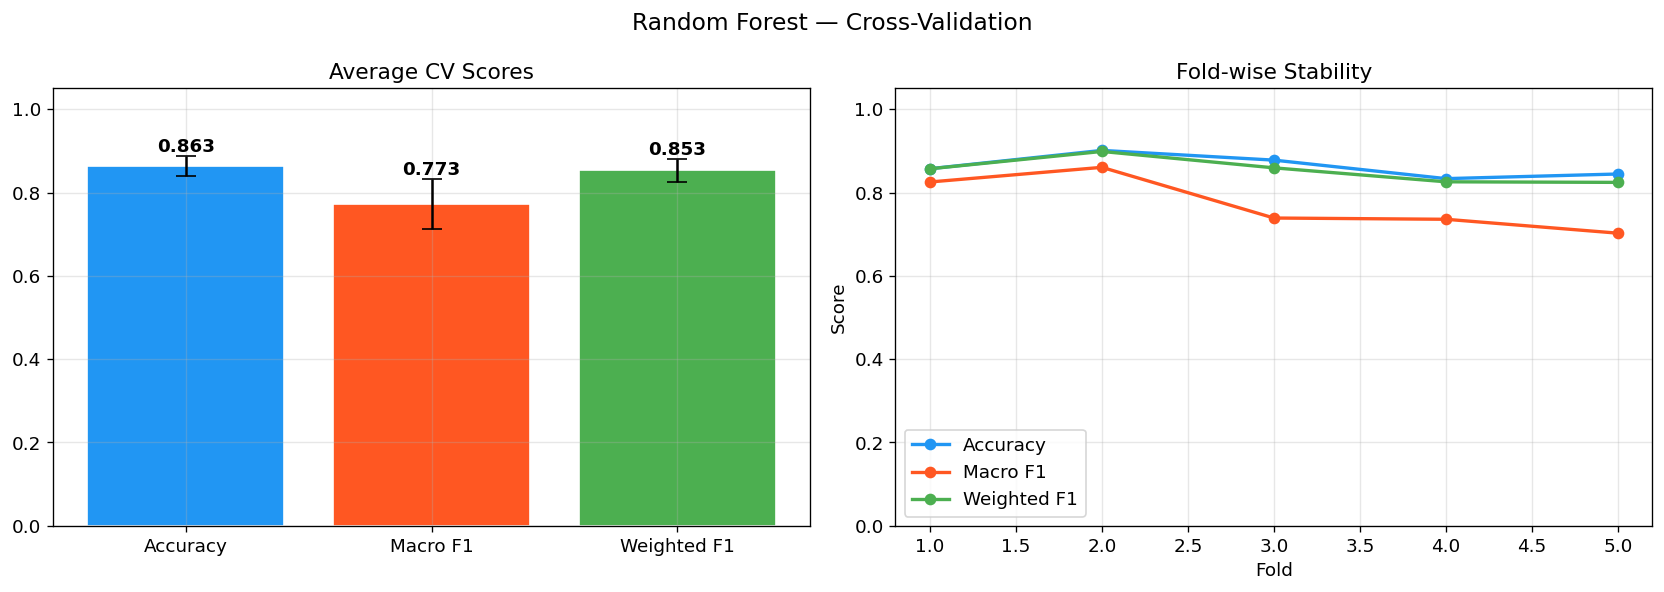

In [13]:
# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = ['Accuracy', 'Macro F1', 'Weighted F1']
means = [cv_results[f'test_{m}'].mean() for m in ['accuracy', 'f1_macro', 'f1_weighted']]
stds = [cv_results[f'test_{m}'].std() for m in ['accuracy', 'f1_macro', 'f1_weighted']]
axes[0].bar(names, means, yerr=stds, capsize=6, color=['#2196F3', '#FF5722', '#4CAF50'], edgecolor='white')
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.01, f'{m:.3f}', ha='center', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Average CV Scores')

for key, label, c in [('test_accuracy','Accuracy','#2196F3'), ('test_f1_macro','Macro F1','#FF5722'), ('test_f1_weighted','Weighted F1','#4CAF50')]:
    axes[1].plot(range(1,6), cv_results[key], 'o-', label=label, color=c, linewidth=2)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Score')
axes[1].set_title('Fold-wise Stability')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.suptitle('Random Forest — Cross-Validation', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Train on Full Training Set

In [14]:
model.fit(X_train_ready, y_train)
print(f"Trained with {model.n_estimators} trees, OOB Score: {model.oob_score_:.4f}")

Trained with 300 trees, OOB Score: 0.8739


## 8. Test Set Evaluation

Now we test on data the model has never seen.

In [15]:
y_pred = model.predict(X_test_ready)
y_proba = model.predict_proba(X_test_ready)

print("Test Results:")
print(f"  Accuracy:     {accuracy_score(y_test, y_pred):.4f}")
print(f"  Macro F1:     {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Weighted F1:  {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=class_names, digits=4))

Test Results:
  Accuracy:     0.8938
  Macro F1:     0.8560
  Weighted F1:  0.8935

              precision    recall  f1-score   support

         CIS     0.7500    0.7500    0.7500         8
        PPMS     0.8750    0.8400    0.8571        25
        RRMS     0.9286    0.9455    0.9369        55
        SPMS     0.8800    0.8800    0.8800        25

    accuracy                         0.8938       113
   macro avg     0.8584    0.8539    0.8560       113
weighted avg     0.8933    0.8938    0.8935       113



### Confusion Matrix

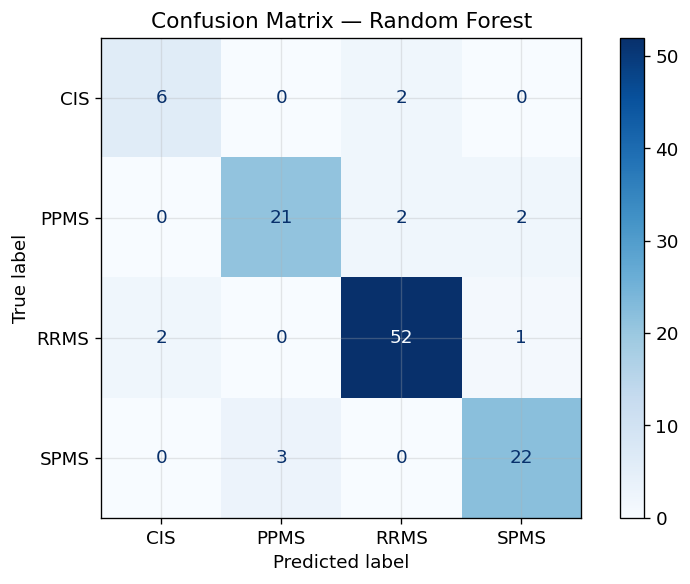

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

### ROC Curves

Closer to the top-left corner = better. AUC of 1.0 is perfect, 0.5 is random guessing.

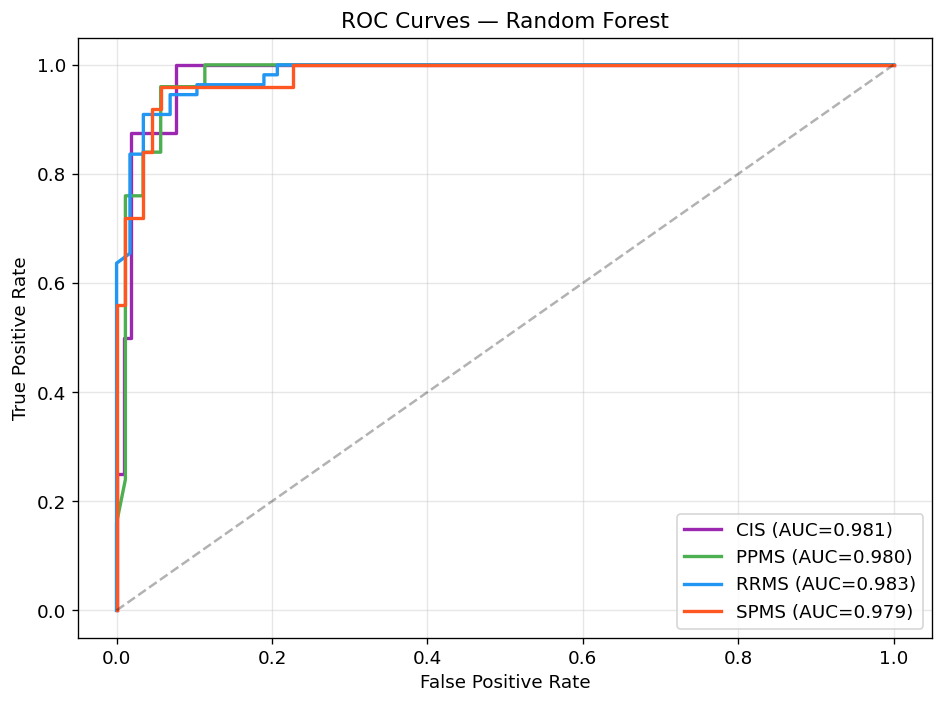

Overall ROC-AUC: 0.9805


In [17]:
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))

fig, ax = plt.subplots(figsize=(8, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})', color=COLORS.get(name))
ax.plot([0,1],[0,1],'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Random Forest')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Overall ROC-AUC: {roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro'):.4f}")

### Precision-Recall Curves

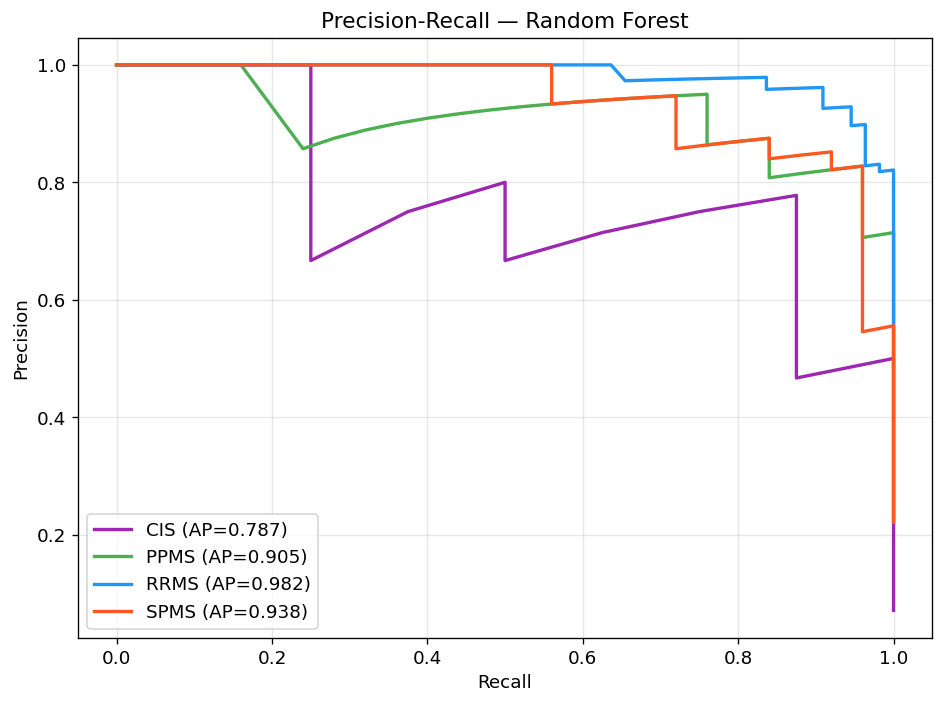

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, name in enumerate(class_names):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    ax.plot(rec, prec, linewidth=2, label=f'{name} (AP={ap:.3f})', color=COLORS.get(name))
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall — Random Forest')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 9. Feature Importance

Which features does the model rely on most?

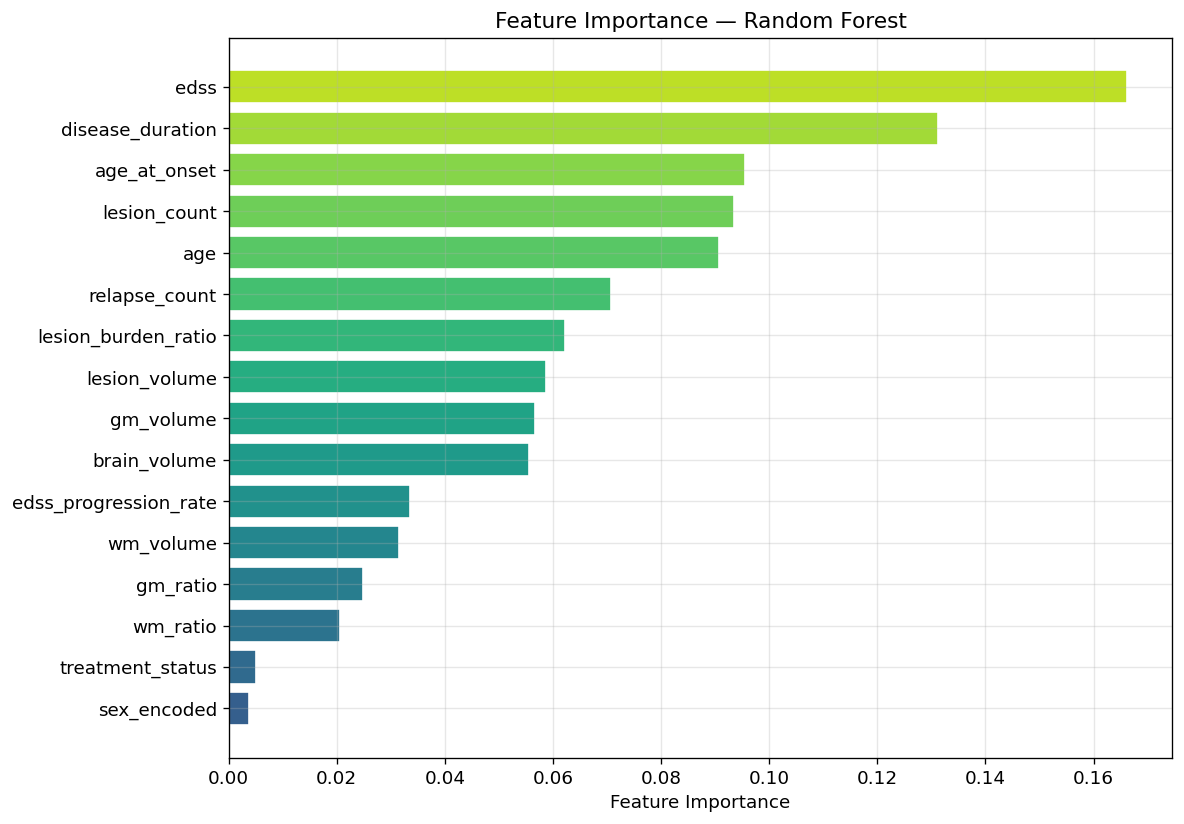

Top 5 features:
  edss                           0.1663
  disease_duration               0.1312
  age_at_onset                   0.0954
  lesion_count                   0.0935
  age                            0.0907


In [19]:
imp = model.feature_importances_
imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': imp}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['Feature'], imp_df['Importance'],
        color=plt.cm.viridis(np.linspace(0.3, 0.9, len(imp_df))), edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

print("Top 5 features:")
for _, row in imp_df.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Feature']:30s} {row['Importance']:.4f}")

## 10. Summary Dashboard

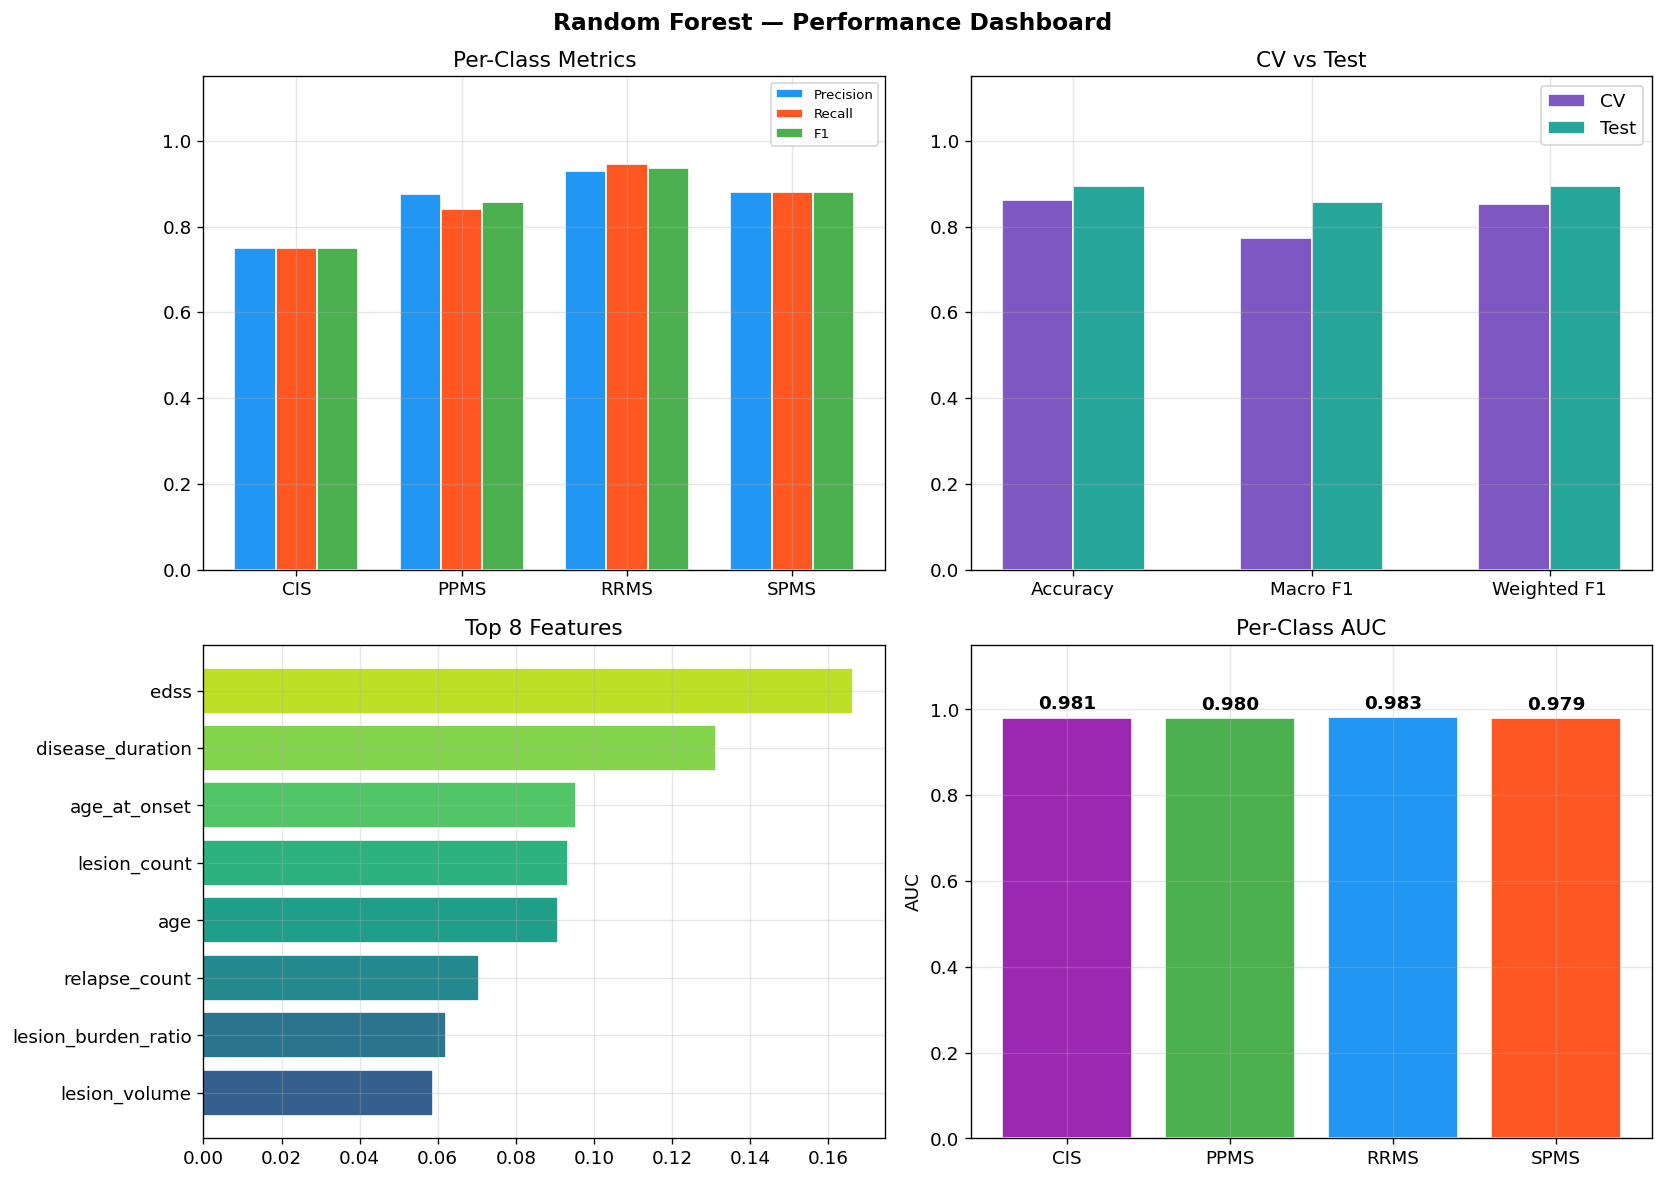

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Per-class metrics
p = precision_score(y_test, y_pred, average=None)
r = recall_score(y_test, y_pred, average=None)
f = f1_score(y_test, y_pred, average=None)
x = np.arange(len(class_names))
w = 0.25
axes[0,0].bar(x-w, p, w, label='Precision', color='#2196F3', edgecolor='white')
axes[0,0].bar(x, r, w, label='Recall', color='#FF5722', edgecolor='white')
axes[0,0].bar(x+w, f, w, label='F1', color='#4CAF50', edgecolor='white')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(class_names)
axes[0,0].set_title('Per-Class Metrics'); axes[0,0].legend(fontsize=8); axes[0,0].set_ylim(0,1.15)

# CV vs Test
acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average='macro')
f1w = f1_score(y_test, y_pred, average='weighted')
cv_m = [cv_results['test_accuracy'].mean(), cv_results['test_f1_macro'].mean(), cv_results['test_f1_weighted'].mean()]
t_m = [acc, f1m, f1w]
x2 = np.arange(3)
axes[0,1].bar(x2-0.15, cv_m, 0.3, label='CV', color='#7E57C2', edgecolor='white')
axes[0,1].bar(x2+0.15, t_m, 0.3, label='Test', color='#26A69A', edgecolor='white')
axes[0,1].set_xticks(x2); axes[0,1].set_xticklabels(['Accuracy','Macro F1','Weighted F1'])
axes[0,1].set_title('CV vs Test'); axes[0,1].legend(); axes[0,1].set_ylim(0,1.15)

# Feature importance
imp = model.feature_importances_
imp_df2 = pd.DataFrame({'Feature': feature_cols, 'Importance': imp}).sort_values('Importance').tail(8)
axes[1,0].barh(imp_df2['Feature'], imp_df2['Importance'],
               color=plt.cm.viridis(np.linspace(0.3,0.9,len(imp_df2))), edgecolor='white')
axes[1,0].set_title('Top 8 Features')

# Per-class AUC
aucs = [auc(*roc_curve(y_test_bin[:,i], y_proba[:,i])[:2]) for i in range(len(class_names))]
axes[1,1].bar(class_names, aucs, color=[COLORS[n] for n in class_names], edgecolor='white')
for i,v in enumerate(aucs): axes[1,1].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[1,1].set_ylabel('AUC'); axes[1,1].set_title('Per-Class AUC'); axes[1,1].set_ylim(0,1.15)

fig.suptitle('Random Forest — Performance Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

Random Forest captures nonlinear patterns with no scaling needed. OOB score gives free validation, and feature importance shows what matters most.